<a href="https://colab.research.google.com/github/rafa120207-lgtm/1TIAPGML/blob/main/cp2_machinelearning_arvore_decisao_banco_digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CP2 — Árvore de Decisão para Aprovação de Limite de Cartão
### Cenário: Banco Digital Brasileiro

**Disciplina:** Machine Learning — FIAP  
**Entrega:** 16/05/2026

**Integrantes do grupo:**
- Rafael Gonçalves - RM569461
- Gustavo Reatti Sela- RM 571545
- Charles Augusto Miranda da Silva - RM571908
- Anthony Prado Pereira- RM572985
- Guilherme Araujo Pinto - RM569863

---

### Contexto de Negócio

Atuamos como cientistas de dados em um banco digital brasileiro. Hoje, a decisão de aprovar
ou negar pedidos de aumento de limite de cartão é feita por regras manuais ("if-else") que
produzem dois problemas caros:

1. **Falsos negativos** — negar aumento para clientes bons (perda de receita).
2. **Falsos positivos** — aprovar aumento para clientes arriscados (risco de calote).

A equipe de risco quer um modelo **mais inteligente que regras manuais**, mas **interpretável**,
porque precisa explicar cada decisão para auditoria e órgãos reguladores (Bacen, LGPD).
A **Árvore de Decisão** atende exatamente esses dois requisitos: aprende padrões dos dados
históricos e gera regras legíveis em forma de "se ... então ...".

### Objetivos do trabalho

1. Explorar os dados (EDA).
2. Treinar uma Árvore de Decisão base.
3. Visualizar e interpretar as regras geradas.
4. Realizar ao menos 2 experimentos controlando complexidade (profundidade, etc.) e discutir
   o trade-off entre **acurácia** e **interpretabilidade** + risco de **overfitting**.


## Sumário

1. [EDA — Análise Exploratória](#1)  *(Pessoa 1 — terça)*
2. [Pré-processamento e Split](#2)  *(Pessoa 2 — quarta)*
3. [Árvore de Decisão Base + Avaliação](#3)  *(Pessoa 2 — quarta)*
4. [Visualização e Interpretação da Árvore](#4)  *(Pessoa 3 — quinta)*
5. [Experimentos com Complexidade da Árvore](#5)  *(Pessoa 4 — sexta)*
6. [Conclusões e Recomendações para o Banco](#6)  *(Todos — sábado)*


<a id='1'></a>
# 1. EDA — Análise Exploratória dos Dados

> **Responsável:** Pessoa 1  
> **Objetivo desta seção:** Entender o dataset antes de modelar.
> Não dá para treinar um modelo bom sem antes responder: *Quais variáveis existem?
> Estão limpas? Como se relacionam com o alvo (`aprovado`)?*


## 1.1 Importação de bibliotecas e carregamento dos dados

In [2]:
# Bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carregamento do dataset
df = pd.read_csv('clientes_limite_cartao_58000.csv')

print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')
df.head()

Linhas: 58,000 | Colunas: 7


,renda_mensal,limite_atual,limite_solicitado,meses_como_cliente,atrasos_12m,score_interno,aprovado
0,6984.20,4127.07,5760.13,61,0,572,1
1,4736.16,1730.20,2235.60,64,0,452,0
2,4455.71,2194.26,3552.71,108,1,662,1
3,4455.76,897.61,814.38,69,2,300,0
4,12624.29,6819.45,9872.53,74,1,841,1


## 1.2 Estrutura e qualidade dos dados

Antes de qualquer análise estatística, precisamos checar:
- **Tipos das variáveis** — todas numéricas? Categóricas precisariam de encoding.
- **Valores faltantes (NaN)** — afetariam o treino da árvore.
- **Duplicatas** — podem enviesar a avaliação.


In [3]:
# Tipos e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58000 entries, 0 to 57999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   renda_mensal        58000 non-null  float64
 1   limite_atual        58000 non-null  float64
 2   limite_solicitado   58000 non-null  float64
 3   meses_como_cliente  58000 non-null  int64  
 4   atrasos_12m         58000 non-null  int64  
 5   score_interno       58000 non-null  int64  
 6   aprovado            58000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 3.1 MB


In [4]:
# Verificação de nulos e duplicatas
print('Valores faltantes por coluna:')
print(df.isnull().sum())
print(f'\nLinhas duplicadas: {df.duplicated().sum()}')

Valores faltantes por coluna:
renda_mensal          0
limite_atual          0
limite_solicitado     0
meses_como_cliente    0
atrasos_12m           0
score_interno         0
aprovado              0
dtype: int64

Linhas duplicadas: 0


**Análise:**

- O dataset tem **58.000 registros** e **7 colunas**, todas numéricas (`int64` ou `float64`).
- Não há valores faltantes — não precisaremos de imputação.
- Não há duplicatas — cada linha é um pedido único.
- A coluna `aprovado` é o nosso **target binário** (0 = negado, 1 = aprovado).

Isso significa que podemos ir direto para a análise estatística sem etapas de limpeza pesada.


## 1.3 Estatísticas descritivas

Vamos olhar média, mediana, desvio padrão, mínimos e máximos de cada variável
para identificar outliers grosseiros e entender as escalas.


In [5]:
df.describe().round(2)

,renda_mensal,limite_atual,limite_solicitado,meses_como_cliente,atrasos_12m,score_interno,aprovado
count,58000.00,58000.00,58000.00,58000.00,58000.00,58000.00,58000.00
mean,6002.54,2116.18,3492.49,60.42,0.70,600.43,0.55
std,3540.53,1594.33,2931.88,34.69,0.84,146.58,0.50
min,1013.81,500.00,500.00,1.00,0.00,300.00,0.00
25%,3397.45,973.36,1470.85,30.00,0.00,498.00,0.00
50%,5199.54,1664.62,2614.57,60.00,1.00,599.00,1.00
75%,7742.59,2770.98,4550.69,91.00,1.00,700.00,1.00
max,30000.00,17495.29,39118.97,120.00,6.00,1000.00,1.00


**Análise:**

- `renda_mensal`: vai de R$ 1.013 a R$ 30.000 (mediana ~R$ 5.200). Distribuição esperada para classe média/baixa.
- `limite_atual` e `limite_solicitado`: o solicitado costuma ser maior que o atual (faz sentido — é um pedido de aumento).
- `meses_como_cliente`: de 1 a >150 meses. Há clientes muito novos e muito antigos.
- `atrasos_12m`: vai de 0 a alguns atrasos. Variável crítica para risco.
- `score_interno`: escala de 300 a 1000 (padrão comum no mercado brasileiro, similar ao Serasa).
- `aprovado`: balanceado em ~55% aprovados / 45% negados — bom para ML.

⚠️ Os valores máximos (renda R$ 30k, limite ~R$ 17k) parecem extremos, mas não necessariamente erros — em um banco digital, há clientes de altíssima renda.


## 1.4 Distribuição do target (`aprovado`)

Saber a proporção de classes é fundamental: se estivesse muito desbalanceado
(ex: 95% negados), teríamos que usar técnicas específicas. Aqui está confortável.


Contagem:
aprovado
1    31636
0    26364
Name: count, dtype: int64

Proporção:
aprovado
1    0.545
0    0.455
Name: proportion, dtype: float64


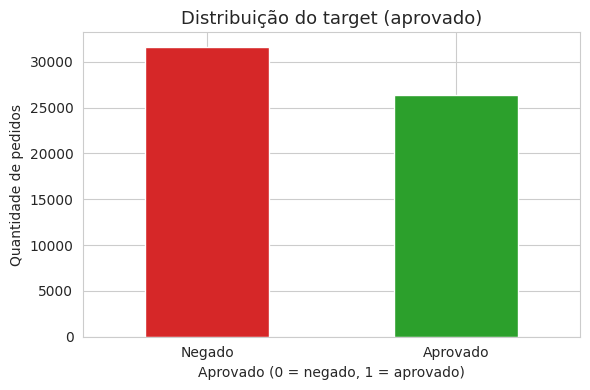

In [6]:
target_counts = df['aprovado'].value_counts()
target_props = df['aprovado'].value_counts(normalize=True).round(3)

print('Contagem:')
print(target_counts)
print('\nProporção:')
print(target_props)

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', color=['#d62728', '#2ca02c'], ax=ax)
ax.set_title('Distribuição do target (aprovado)')
ax.set_xlabel('Aprovado (0 = negado, 1 = aprovado)')
ax.set_ylabel('Quantidade de pedidos')
ax.set_xticklabels(['Negado', 'Aprovado'], rotation=0)
plt.tight_layout()
plt.show()

**Análise:**

O dataset está **razoavelmente balanceado** (~55% / 45%). Isso é positivo:
- Não precisamos aplicar técnicas de balanceamento (SMOTE, class_weight) no modelo base.
- A métrica `accuracy` faz sentido como referência (não estaria viesada pela classe majoritária).
- Ainda assim, vamos olhar **precision, recall e F1** porque os custos de erro são assimétricos no negócio:
    - **Falso positivo** (aprovar arriscado) → calote → prejuízo direto.
    - **Falso negativo** (negar cliente bom) → perda de receita futura.


## 1.5 Distribuição das features (histogramas)

Histogramas mostram a "cara" de cada variável: simétrica, assimétrica, com pico,
cauda longa. Isso ajuda a antecipar comportamentos do modelo.


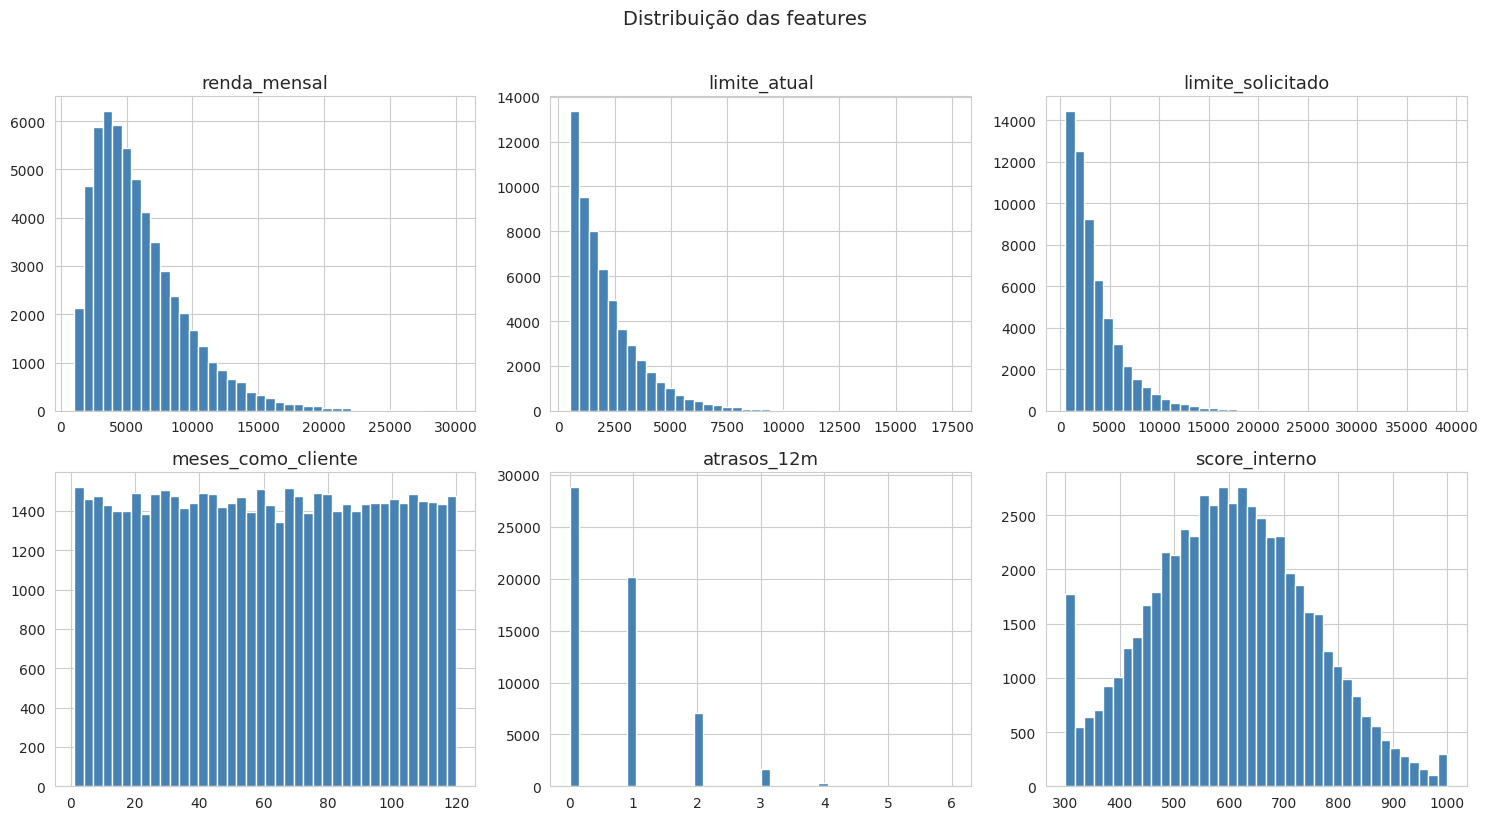

In [7]:
features = ['renda_mensal', 'limite_atual', 'limite_solicitado',
            'meses_como_cliente', 'atrasos_12m', 'score_interno']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribuição das features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análise:**

- `renda_mensal`, `limite_atual`, `limite_solicitado`: distribuição **assimétrica à direita** (cauda longa de valores altos). Comportamento típico de variáveis financeiras.
- `meses_como_cliente`: bem distribuída, mas com mais clientes "recentes" (até 50 meses).
- `atrasos_12m`: concentrada em 0 e 1 (maioria dos clientes não tem atrasos), com cauda em valores maiores.
- `score_interno`: aproximadamente **normal**, centrada em ~600 — coerente com a faixa de risco médio do mercado.

Para Árvores de Decisão, **a forma da distribuição não é problema** (diferente de regressão linear), porque a árvore divide os dados por thresholds. Isso é uma das vantagens de usar essa família de modelos.


## 1.6 Features vs Target (boxplots)

Aqui é onde a EDA começa a ser realmente útil para modelagem:
queremos ver **quais variáveis separam visualmente** clientes aprovados de negados.
Se uma variável é muito parecida entre as duas classes, ela tem pouco poder preditivo.


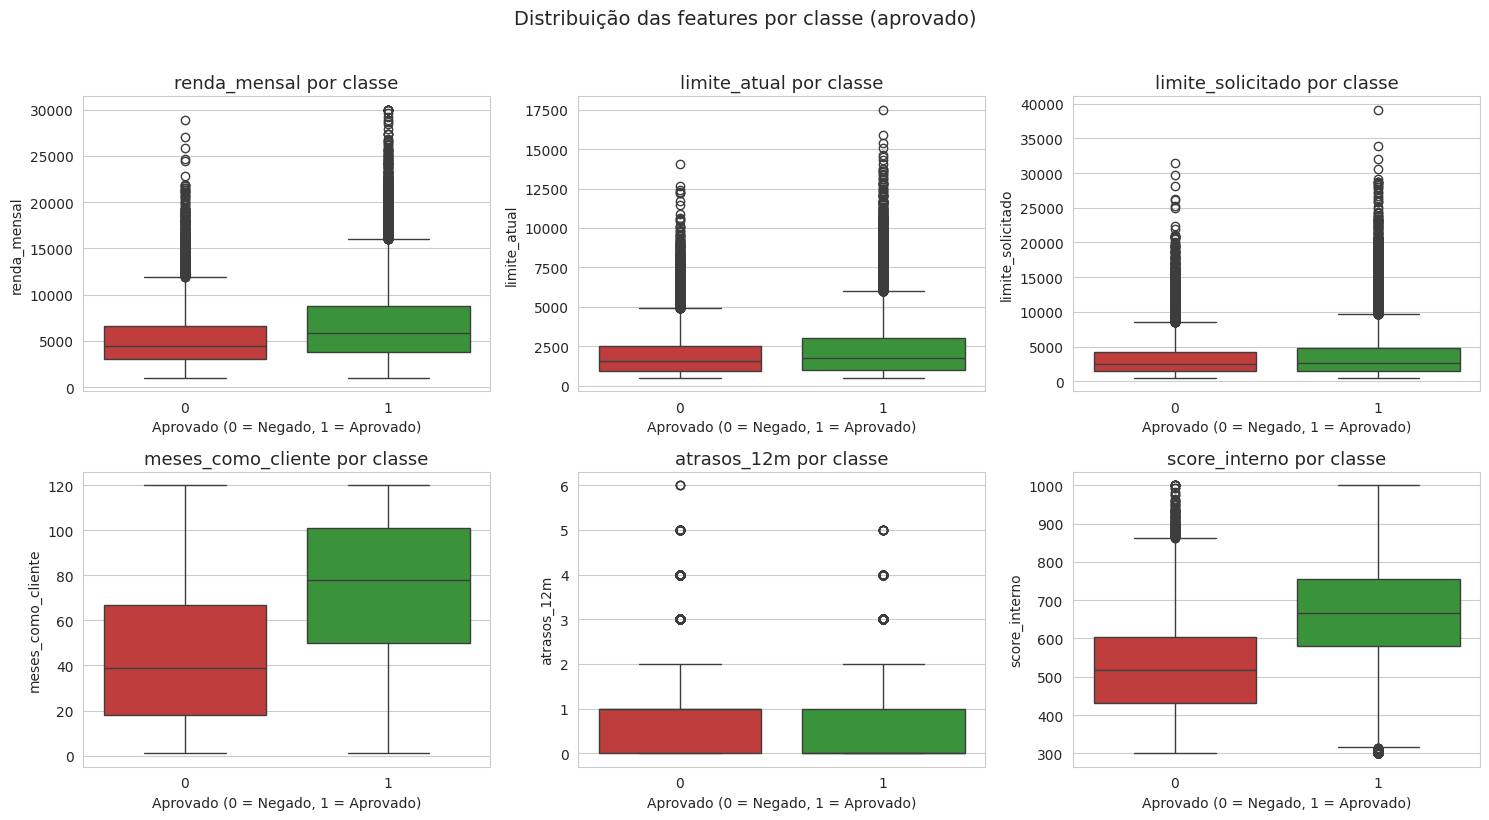

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='aprovado', y=col, ax=ax,
                hue='aprovado', palette=['#d62728', '#2ca02c'],
                legend=False)
    ax.set_title(f'{col} por classe')
    ax.set_xlabel('Aprovado (0 = Negado, 1 = Aprovado)')
plt.suptitle('Distribuição das features por classe (aprovado)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análise — quais variáveis mais separam as classes?**

- ✅ **`score_interno`**: separação **forte**. Aprovados têm score muito maior. Será a feature mais importante para a árvore.
- ✅ **`meses_como_cliente`**: separação **clara**. Clientes mais antigos são aprovados com mais frequência (faz sentido — o banco tem histórico para avaliar).
- ✅ **`renda_mensal`**: separação **moderada**. Renda mais alta favorece a aprovação.
- ⚠️ **`atrasos_12m`**: aprovados têm menos atrasos (esperado), mas a diferença é menor do que seria de se esperar — provavelmente porque o score interno já absorve essa informação.
- ⚠️ **`limite_atual` e `limite_solicitado`**: separação **fraca**. As distribuições são muito parecidas entre as classes.

**Implicação para o modelo:** esperamos que a árvore use `score_interno` e `meses_como_cliente` como variáveis principais de decisão nos primeiros nós.


## 1.7 Mapa de correlação

A correlação linear não é o que a árvore usa internamente (ela usa ganho de informação),
mas é útil para nós, humanos, entendermos as relações entre variáveis.


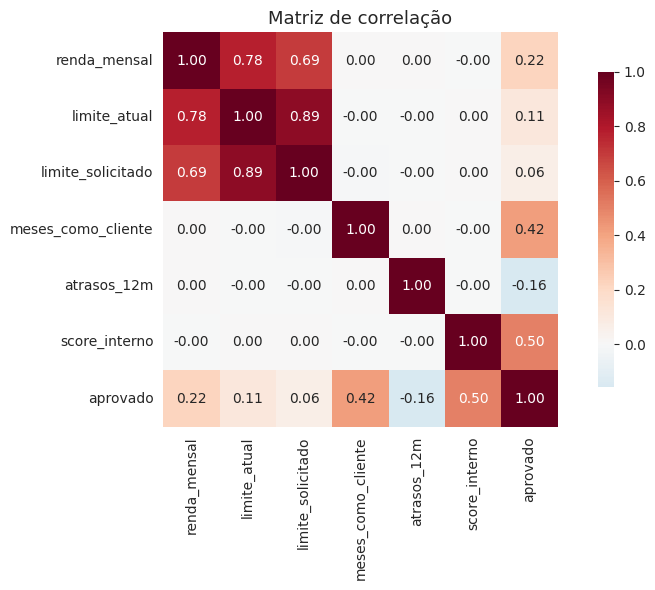


Correlação com o target (aprovado):
aprovado              1.000
score_interno         0.501
meses_como_cliente    0.416
renda_mensal          0.223
limite_atual          0.113
limite_solicitado     0.065
atrasos_12m          -0.158
Name: aprovado, dtype: float64


In [9]:
plt.figure(figsize=(9, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

print('\nCorrelação com o target (aprovado):')
print(corr['aprovado'].sort_values(ascending=False).round(3))

**Análise das correlações com o target:**

| Variável | Correlação | Leitura |
|---|---|---|
| `score_interno` | **+0.50** | Mais score → mais aprovação. Variável dominante. |
| `meses_como_cliente` | **+0.42** | Mais tempo de relacionamento → mais aprovação. |
| `renda_mensal` | +0.22 | Influência moderada, positiva. |
| `limite_atual` | +0.11 | Influência fraca. |
| `limite_solicitado` | +0.07 | Quase nula. |
| `atrasos_12m` | **-0.16** | Mais atrasos → menos aprovação. |

**Não observamos multicolinearidade preocupante entre features** (todas as correlações entre pares de features estão abaixo de 0.7). Mesmo se houvesse, Árvores de Decisão são robustas a multicolinearidade — não é um problema.


## 1.8 Conclusões da EDA

**Sobre os dados:**
- 58.000 pedidos, sem nulos, sem duplicatas, target balanceado.
- Todas as features são numéricas. Não precisamos de encoding.
- Não há indícios de erros grosseiros nos dados.

**Sobre o que esperar do modelo:**
- A Árvore deve priorizar `score_interno` e `meses_como_cliente` nos primeiros splits.
- `renda_mensal` e `atrasos_12m` devem aparecer em nós secundários.
- `limite_atual` e `limite_solicitado` podem ter importância baixa.

**Sobre o negócio:**
- O dataset é grande o suficiente (58k) para treinar uma árvore robusta sem risco de
  underfitting por falta de dados.
- A interpretabilidade da árvore vai casar bem com a necessidade regulatória do banco.

➡️ **Próximo passo:** dividir treino/teste e treinar o primeiro modelo (Seção 2 e 3).


<a id='2'></a>
# 2. Pré-processamento e Split treino/teste

> **Responsável:** Pessoa 2 — Quarta-feira  
> **Tempo estimado:** 30-45 min

## ✅ O que você precisa fazer aqui

1. Separar X (features) e y (target `aprovado`).
2. Fazer split treino/teste com `train_test_split`:
   - `test_size=0.2` (20% para teste)
   - `random_state=42` (reprodutibilidade)
   - `stratify=y` (manter a proporção do target nos dois splits — IMPORTANTE)
3. Imprimir o shape dos splits e confirmar que a proporção de `aprovado` ficou
   parecida em treino e teste.

## 💡 Dicas

- **Não precisa escalar/normalizar** (StandardScaler, MinMaxScaler) — Árvores de Decisão
  não se importam com escala. Isso é diferente de regressão logística ou redes neurais.
- **Não precisa criar dummies** — todas as features já são numéricas.
- Use o `stratify` para garantir que treino e teste tenham a mesma proporção de aprovados/negados.


In [10]:
# >>>>>>>>>> CÓDIGO DA PESSOA 2 — Pré-processamento e split <<<<<<<<<<
from sklearn.model_selection import train_test_split

# 1. Separa X e y
# X = df.drop(...)
# y = df[...]

# 2. Split treino/teste estratificado
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# 3. Imprimir shapes e proporções
# print(f'Treino: {X_train.shape}  | Teste: {X_test.shape}')
# print(f'Proporção de aprovado no treino: {y_train.mean():.3f}')
# print(f'Proporção de aprovado no teste:  {y_test.mean():.3f}')


**Análise (preencher após rodar):**

- Tamanho do treino: _____ linhas
- Tamanho do teste: _____ linhas
- Proporção de aprovados manteve-se em ambos os splits? Sim/Não.


<a id='3'></a>
# 3. Árvore de Decisão Base + Avaliação

> **Responsável:** Pessoa 2 — Quarta-feira  
> **Tempo estimado:** 1h

## ✅ O que você precisa fazer aqui

1. Instanciar um `DecisionTreeClassifier` **sem limitar profundidade** (modelo base).
   Use `random_state=42` para reprodutibilidade.
2. Treinar no `X_train`, `y_train`.
3. Prever em `X_test`.
4. Avaliar com:
   - `accuracy_score`
   - `classification_report` (mostra precision, recall, f1 por classe)
   - `confusion_matrix` (visualize com `ConfusionMatrixDisplay` ou `sns.heatmap`)
5. **Reportar a profundidade real da árvore** (`clf.get_depth()`) e o número de folhas
   (`clf.get_n_leaves()`). Isso vai ser referência para discutir overfitting depois.

## 💡 Dicas

- Avalie **tanto no treino quanto no teste**. Se a acurácia no treino for ~100% e no teste
  for bem menor, é overfitting clássico — vai ser um ponto importante para discutir.
- Comente os resultados em markdown logo abaixo do código.

## 🎯 Pergunta a responder em markdown:

> "Qual é o erro mais caro para o banco: aprovar um cliente arriscado (FP) ou negar um cliente bom (FN)? Como isso se relaciona com `precision` e `recall` da classe 1?"


In [11]:
# >>>>>>>>>> CÓDIGO DA PESSOA 2 — Árvore base + avaliação <<<<<<<<<<
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# 1. Instanciar (sem limitar profundidade)
# clf_base = DecisionTreeClassifier(random_state=42)

# 2. Treinar
# clf_base.fit(X_train, y_train)

# 3. Prever
# y_pred_train = clf_base.predict(X_train)
# y_pred_test  = clf_base.predict(X_test)

# 4. Métricas
# print(f'Profundidade: {clf_base.get_depth()}  |  Folhas: {clf_base.get_n_leaves()}')
# print(f'Acurácia treino: {accuracy_score(y_train, y_pred_train):.4f}')
# print(f'Acurácia teste:  {accuracy_score(y_test,  y_pred_test):.4f}')
# print('\nClassification report (teste):')
# print(classification_report(y_test, y_pred_test, target_names=['Negado', 'Aprovado']))

# 5. Matriz de confusão
# fig, ax = plt.subplots(figsize=(5, 4))
# ConfusionMatrixDisplay.from_predictions(
#     y_test, y_pred_test, display_labels=['Negado', 'Aprovado'],
#     cmap='Blues', ax=ax
# )
# plt.title('Matriz de confusão — Teste')
# plt.show()


**Análise (preencher após rodar):**

- Profundidade da árvore base: _____
- Número de folhas: _____
- Acurácia treino: _____
- Acurácia teste: _____
- Há sinais de overfitting? (treino >> teste?): _____
- Qual erro é mais caro para o banco e por quê?: _____


<a id='4'></a>
# 4. Visualização e Interpretação da Árvore

> **Responsável:** Pessoa 3 — Quinta-feira  
> **Tempo estimado:** 1h-1h30

## ✅ O que você precisa fazer aqui

1. **Plotar a árvore** com `sklearn.tree.plot_tree`.
   - ⚠️ A árvore base é GIGANTE (provavelmente >15 níveis). Plote uma versão **limitada a `max_depth=3` ou `4`** para conseguir visualizar. Use `plt.figure(figsize=(20, 10))`.
2. **Extrair regras em texto** com `sklearn.tree.export_text`. Use `max_depth=3` aqui também.
3. **Importância das features**: `clf_base.feature_importances_`. Faça um gráfico de barras
   horizontal ordenado.
4. **Interpretar as 3 regras mais importantes**: escreva em linguagem de negócio:
   "Se score_interno > 580 E meses_como_cliente > 30 → aprovar".
   Não copie o texto da árvore, **traduza**.

## 💡 Dicas

- `feature_names=X.columns.tolist()` e `class_names=['Negado', 'Aprovado']` deixam tudo muito mais legível.
- `filled=True` no `plot_tree` colore os nós por classe — ótimo para apresentação.
- Se for plotar a árvore inteira, salve como SVG ou PNG fora do notebook (ela é enorme).

## 🎯 Pergunta a responder em markdown:

> "Se um auditor do Bacen pedisse para você explicar por que o modelo negou um pedido específico, como você usaria a árvore para responder?"


In [12]:
# >>>>>>>>>> CÓDIGO DA PESSOA 3 — Visualização e interpretação <<<<<<<<<<
from sklearn.tree import plot_tree, export_text

# 1. Plotar árvore limitada a max_depth=3
# plt.figure(figsize=(22, 10))
# plot_tree(
#     clf_base,
#     max_depth=3,
#     feature_names=X.columns.tolist(),
#     class_names=['Negado', 'Aprovado'],
#     filled=True, rounded=True, fontsize=10
# )
# plt.title('Árvore de Decisão (primeiros 3 níveis)')
# plt.show()

# 2. Regras em texto
# regras = export_text(clf_base, feature_names=X.columns.tolist(), max_depth=3)
# print(regras)

# 3. Importância das features
# importancias = pd.Series(clf_base.feature_importances_,
#                          index=X.columns).sort_values()
# plt.figure(figsize=(8, 5))
# importancias.plot(kind='barh', color='teal')
# plt.title('Importância das features (árvore base)')
# plt.xlabel('Importância')
# plt.tight_layout()
# plt.show()
# print(importancias.sort_values(ascending=False).round(4))


**Interpretação das regras (preencher em linguagem de negócio):**

Regra 1 (caminho dominante de **aprovação**):
> Se ___ E ___ → o banco aprova com confiança alta.

Regra 2 (caminho dominante de **negação**):
> Se ___ → o banco nega.

Regra 3 (caso de fronteira):
> ___

**Resposta para o auditor do Bacen:**
> ___


<a id='5'></a>
# 5. Experimentos com Complexidade da Árvore

> **Responsável:** Pessoa 4 — Sexta-feira  
> **Tempo estimado:** 1h30-2h

## ✅ O que você precisa fazer aqui

O enunciado pede **pelo menos 2 experimentos** controlando profundidade/complexidade.
Vamos fazer:

### Experimento 1 — Variando `max_depth`

Treine árvores com `max_depth` em `[2, 3, 5, 7, 10, 15, None]` e compare:
- Acurácia no **treino**
- Acurácia no **teste**
- Profundidade real e número de folhas
- F1-score da classe positiva (aprovado)

Plote um gráfico com 2 linhas: acurácia treino vs acurácia teste em função de `max_depth`.
**A divergência entre as duas curvas é o overfitting.**

### Experimento 2 — Variando `min_samples_leaf`

Esse parâmetro define o número MÍNIMO de amostras em cada folha. Quanto maior, menos
a árvore "decora" casos individuais. Teste valores como `[1, 5, 20, 50, 100, 500]` com
`max_depth=10` fixo.

## 💡 Dicas

- Monte uma função `treinar_e_avaliar(params)` que recebe os hiperparâmetros e retorna
  um dicionário com as métricas. Aí você roda em loop e monta um DataFrame para tabela.
- Use `from sklearn.metrics import f1_score`.

## 🎯 Pergunta a responder em markdown:

> "Qual configuração você recomendaria para colocar em produção no banco e por quê?
> Considere o trade-off entre desempenho preditivo e interpretabilidade
> (uma árvore com 200 folhas é difícil de explicar para um auditor)."


In [13]:
# >>>>>>>>>> CÓDIGO DA PESSOA 4 — Experimentos <<<<<<<<<<
from sklearn.metrics import f1_score

def treinar_e_avaliar(**params):
    clf = DecisionTreeClassifier(random_state=42, **params)
    clf.fit(X_train, y_train)
    return {
        'acc_treino': accuracy_score(y_train, clf.predict(X_train)),
        'acc_teste':  accuracy_score(y_test,  clf.predict(X_test)),
        'f1_teste':   f1_score(y_test, clf.predict(X_test)),
        'profundidade': clf.get_depth(),
        'n_folhas': clf.get_n_leaves(),
    }

# ===== Experimento 1: max_depth =====
# resultados_depth = []
# for d in [2, 3, 5, 7, 10, 15, None]:
#     r = treinar_e_avaliar(max_depth=d)
#     r['max_depth'] = d
#     resultados_depth.append(r)
# df_exp1 = pd.DataFrame(resultados_depth)
# print(df_exp1)

# Plot do trade-off (treino vs teste)
# plt.figure(figsize=(8, 5))
# # plt.plot(...) — preencher
# plt.xlabel('max_depth')
# plt.ylabel('Acurácia')
# plt.title('Trade-off treino x teste em função de max_depth')
# plt.legend()
# plt.show()

# ===== Experimento 2: min_samples_leaf =====
# resultados_leaf = []
# for n in [1, 5, 20, 50, 100, 500]:
#     r = treinar_e_avaliar(max_depth=10, min_samples_leaf=n)
#     r['min_samples_leaf'] = n
#     resultados_leaf.append(r)
# df_exp2 = pd.DataFrame(resultados_leaf)
# print(df_exp2)


**Análise dos experimentos (preencher após rodar):**

### Experimento 1 — `max_depth`
- A acurácia de treino cresce até atingir 100% quando `max_depth=None` → árvore decora os dados.
- A acurácia de teste estabiliza/cai a partir de `max_depth=___` → ponto ótimo do trade-off.
- **Conclusão:** ___

### Experimento 2 — `min_samples_leaf`
- Aumentar `min_samples_leaf` reduz o overfitting porque ___
- **Conclusão:** ___

### 🏆 Modelo recomendado para produção
**Configuração:** `max_depth=___`, `min_samples_leaf=___`  
**Justificativa:** ___


<a id='6'></a>
# 6. Conclusões e Recomendações para o Banco

> **Responsável:** Todos — Sábado  
> **Tempo estimado:** 1h

## ✅ Fechamento do trabalho

Escrevam aqui um texto-conclusão (15-25 linhas em markdown) cobrindo:

1. **Resumo do que foi feito** — EDA, modelo base, experimentos.
2. **Modelo final recomendado** — hiperparâmetros + métricas finais.
3. **Comparação com as regras manuais do banco** — por que a árvore é melhor?
   (provavelmente: mais nuance, mais variáveis combinadas, métricas mensuráveis)
4. **Por que árvore e não outro modelo?** — interpretabilidade, exigências regulatórias.
5. **Limitações** — o que ainda pode ser melhorado? (ex.: ensemble como Random Forest
   teria mais acurácia, mas perderia interpretabilidade; precisaríamos de mais features
   transacionais; o dataset pode estar enviesado por decisões manuais antigas).
6. **Próximos passos** — A/B test em produção? Monitoramento? Comparação com XGBoost?


---
### Considerações finais

Esse trabalho mostra um caso de uso clássico onde a **interpretabilidade vale mais que a acurácia máxima**: em finanças regulada, precisamos explicar cada decisão. A Árvore de Decisão entrega esse equilíbrio.

**Referências:**
- Scikit-learn docs — `DecisionTreeClassifier`: https://scikit-learn.org/stable/modules/tree.html
- Breiman, L. (1984). *Classification and Regression Trees*. (artigo seminal)
